# 🌲 Random Forest (Iris Example)

This notebook shows a simple Random Forest classification example using the Iris dataset.

In [1]:
# Step 1: Import libraries
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [2]:
# Step 2: Load dataset
iris = load_iris()
X = iris.data
y = iris.target

print('Feature shape:', X.shape)
print('Target shape:', y.shape)

Feature shape: (150, 4)
Target shape: (150,)


In [3]:
# Step 3: Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('Train size:', X_train.shape)
print('Test size:', X_test.shape)

Train size: (120, 4)
Test size: (30, 4)


In [4]:
# Step 4: Create model
model = RandomForestClassifier(n_estimators=100, random_state=42)

In [5]:
# Step 5: Train model
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [6]:
# Step 6: Predict
y_pred = model.predict(X_test)

print('Predictions:', y_pred[:10])

Predictions: [1 0 2 1 1 0 1 2 1 1]


In [7]:
# Step 7: Accuracy
accuracy = accuracy_score(y_test, y_pred)
print('Accuracy:', accuracy)

Accuracy: 1.0


In [8]:
# Step 8: Predict one sample
sample = [[5.1, 3.5, 1.4, 0.2]]
prediction = model.predict(sample)

print('Predicted class:', prediction)
print('Predicted flower:', iris.target_names[prediction[0]])

Predicted class: [0]
Predicted flower: setosa


In [9]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

# Load data
iris = load_iris()
X = iris.data
y = iris.target

# Keep only 2 classes for simple AUC example
X = X[y != 2]
y = y[y != 2]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Get predicted probabilities for class 1
y_prob = model.predict_proba(X_test)[:, 1]

# Calculate AUC
auc = roc_auc_score(y_test, y_prob)
print("AUC:", auc)

AUC: 1.0


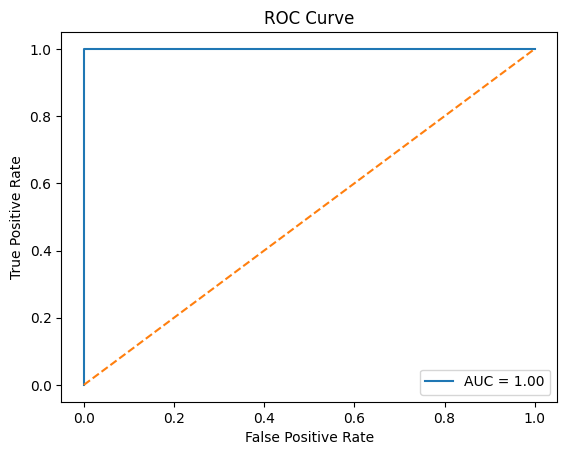

In [10]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()